In [ ]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os

print(os.listdir('/content/drive/MyDrive'))


['Colab Notebooks', 'ALGORITHMS FOR ALL SORTING(MERGE SORT, QUICK SORT AND RADIX SORT) (3).gdoc', 'ALGORITHMS FOR ALL SORTING(MERGE SORT, QUICK SORT AND RADIX SORT) (2).gdoc', 'ALGORITHMS FOR ALL SORTING(MERGE SORT, QUICK SORT AND RADIX SORT) (1).gdoc', 'ALGORITHMS FOR ALL SORTING(MERGE SORT, QUICK SORT AND RADIX SORT).gdoc', 'f bar is 12x²yibar-3yzjbar+2zk bar this is correct f bar u recognised wrong previously give detailed solution .gdoc', 'Registration Certificate.pdf', 'stations.csv', 'swap_events.csv']


In [ ]:
import os

files = os.listdir('/content/drive/MyDrive')

for file in files:
    if file in ['swap_events.csv.gz', 'stations.csv']:
        print("Found:", file)


Found: stations.csv


In [ ]:
import os

files = os.listdir('/content/drive/MyDrive')

for file in files:
    if file in ['swap_events.csv', 'stations.csv']:
        print("Found:", file)

Found: stations.csv
Found: swap_events.csv


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/swap_events.csv"

swap_sample = pd.read_csv(file_path, nrows=5)

print("Columns:")
print(swap_sample.columns.tolist())

print("\nFirst 5 rows:")
display(swap_sample)

Columns:
['event_id', 'rider_id', 'station_id', 'event_ts', 'event_type', 'attempt_seq', 'queue_wait_sec', 'battery_in_id', 'battery_out_id', 'soc_in_pct', 'soh_in_pct', 'soc_out_pct', 'soh_out_pct', 'km_since_last_swap', 'tariff_code', 'list_price_inr', 'discount_inr', 'amount_charged_inr', 'payment_mode', 'energy_to_recharge_kwh', 'station_firmware', 'sync_mode']

First 5 rows:


,event_id,rider_id,station_id,event_ts,event_type,attempt_seq,queue_wait_sec,battery_in_id,battery_out_id,soc_in_pct,...,soh_out_pct,km_since_last_swap,tariff_code,list_price_inr,discount_inr,amount_charged_inr,payment_mode,energy_to_recharge_kwh,station_firmware,sync_mode
0,SW-000000001,RD-1000003,STN-MUM-115,2024-01-01 11:10:56,swap_completed,1,88,BAT-2W-103542,BAT-2W-102547,15.0,...,98.9,80.4,PARTNER,60.0,6.0,54.0,partner_invoice,2.035,v3.2.1,realtime
1,SW-000000002,RD-1000004,STN-HYD-070,2024-01-01 17:13:06,swap_completed,1,148,BAT-2W-105296,BAT-2W-101923,8.3,...,98.2,66.1,PARTNER,60.0,9.0,51.0,partner_invoice,2.157,v3.2.0,realtime
2,SW-000000003,RD-1000005,STN-DEL-046,2024-01-01 20:15:14,swap_completed,1,307,BAT-2W-104732,BAT-2W-102492,11.5,...,99.1,66.6,STD,60.0,0.0,60.0,partner_invoice,2.039,v3.2.0,realtime
3,SW-000000004,RD-1000006,STN-JAI-135,2024-01-01 20:26:07,swap_completed,1,399,BAT-2W-103839,BAT-2W-103267,7.9,...,98.2,65.4,STD,60.0,0.0,60.0,partner_invoice,2.194,v3.2.0,realtime
4,SW-000000005,RD-1000012,STN-PUN-100,2024-01-01 21:13:07,swap_completed,1,201,BAT-2W-104056,BAT-2W-106218,10.5,...,99.9,73.8,STD,60.0,0.0,60.0,partner_invoice,1.971,v3.2.1,realtime


In [ ]:
print(swap_sample["event_type"].value_counts())

event_type
swap_completed    5
Name: count, dtype: int64


In [ ]:
event_types = pd.read_csv(
    file_path,
    usecols=["event_type"]
)

print(event_types["event_type"].value_counts())

event_type
swap_completed               3645809
failed_no_charged_battery     134389
abandoned_queue                68533
cancelled_by_rider             16712
failed_system_error            11570
Name: count, dtype: int64


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/swap_events.csv"

monthly_data = []

for chunk in pd.read_csv(
    file_path,
    usecols=[
        "event_ts",
        "event_type",
        "amount_charged_inr"
    ],
    chunksize=100000
):

    # Convert timestamp
    chunk["event_ts"] = pd.to_datetime(chunk["event_ts"])

    # Create month
    chunk["month"] = chunk["event_ts"].dt.to_period("M").astype(str)

    # Completed swaps
    chunk["completed"] = (
        chunk["event_type"] == "swap_completed"
    ).astype(int)

    # Failures
    chunk["failed"] = chunk["event_type"].isin([
        "failed_no_charged_battery",
        "failed_system_error"
    ]).astype(int)

    # Group this chunk by month
    result = chunk.groupby("month").agg(
        completed_swaps=("completed", "sum"),
        revenue=("amount_charged_inr", "sum"),
        failed_attempts=("failed", "sum"),
        total_attempts=("event_type", "count")
    ).reset_index()

    monthly_data.append(result)

# Combine all chunks
monthly = pd.concat(monthly_data)

# Combine months again because each month appears in multiple chunks
monthly = monthly.groupby("month").agg(
    completed_swaps=("completed_swaps", "sum"),
    revenue=("revenue", "sum"),
    failed_attempts=("failed_attempts", "sum"),
    total_attempts=("total_attempts", "sum")
).reset_index()

# Calculate failure rate
monthly["failure_rate"] = (
    monthly["failed_attempts"] /
    monthly["total_attempts"]
) * 100

print(monthly)

/tmp/ipykernel_1489/1254212603.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk["event_ts"] = pd.to_datetime(chunk["event_ts"])


      month  completed_swaps      revenue  failed_attempts  total_attempts  \
0   2024-01           105490   6318995.20             3008          110348   
1   2024-02           106582   6387614.80             3027          111531   
2   2024-03           118444   7093617.00             3332          123900   
3   2024-04           122836   7370255.80             5775          131818   
4   2024-05           128328   7689594.00            11760          146278   
5   2024-06           133743   8003275.60             9911          148888   
6   2024-07           151824   9879524.60             4186          158688   
7   2024-08           164931  10724296.65             4424          172295   
8   2024-09           187302  12115209.50             5311          195885   
9   2024-10           219838  14577271.65             6148          229901   
10  2024-11           228253  14759655.55             6131          238352   
11  2024-12           252621  16343646.55             7091      

In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/swap_events.csv"

monthly_data = []

for chunk in pd.read_csv(
    file_path,
    usecols=[
        "event_ts",
        "event_type",
        "amount_charged_inr"
    ],
    chunksize=100000
):

    # Convert timestamp
    chunk["event_ts"] = pd.to_datetime(chunk["event_ts"])

    # Create month
    chunk["month"] = chunk["event_ts"].dt.to_period("M").astype(str)

    # Completed swaps
    completed = chunk[chunk["event_type"] == "swap_completed"].copy()

    # Failure events explicitly marked as failures
    failed = chunk["event_type"].isin([
        "failed_no_charged_battery",
        "failed_system_error"
    ])

    # Monthly summary for this chunk
    result = chunk.groupby("month").agg(
        total_attempts=("event_type", "size"),
        failed_attempts=(failed.name if hasattr(failed, "name") else "event_type", "size")
    )

    # Do the calculations separately to avoid counting incorrectly
    summary = chunk.groupby("month").agg(
        total_attempts=("event_type", "size"),
        completed_swaps=("event_type",
                         lambda x: (x == "swap_completed").sum()),
        failed_attempts=("event_type",
                         lambda x: x.isin([
                             "failed_no_charged_battery",
                             "failed_system_error"
                         ]).sum())
    ).reset_index()

    # Revenue ONLY from completed swaps
    revenue = (
        completed.groupby("month")["amount_charged_inr"]
        .sum()
        .reset_index(name="revenue")
    )

    summary = summary.merge(revenue, on="month", how="left")
    monthly_data.append(summary)

# Combine all chunks
monthly = pd.concat(monthly_data, ignore_index=True)

# Combine duplicate months created by chunks
monthly = monthly.groupby("month").agg(
    total_attempts=("total_attempts", "sum"),
    completed_swaps=("completed_swaps", "sum"),
    failed_attempts=("failed_attempts", "sum"),
    revenue=("revenue", "sum")
).reset_index()

# Failure rate
monthly["failure_rate"] = (
    monthly["failed_attempts"] /
    monthly["total_attempts"]
) * 100

monthly = monthly.sort_values("month").reset_index(drop=True)

print(monthly.to_string(index=False))

/tmp/ipykernel_1489/2569457301.py:18: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  chunk["event_ts"] = pd.to_datetime(chunk["event_ts"])


  month  total_attempts  completed_swaps  failed_attempts     revenue  failure_rate
2024-01          110348           105490             3008  6318995.20      2.725922
2024-02          111531           106582             3027  6387614.80      2.714044
2024-03          123900           118444             3332  7093617.00      2.689266
2024-04          131818           122836             5775  7370255.80      4.381041
2024-05          146278           128328            11760  7689594.00      8.039486
2024-06          148888           133743             9911  8003275.60      6.656682
2024-07          158688           151824             4186  9879524.60      2.637881
2024-08          172295           164931             4424 10724296.65      2.567689
2024-09          195885           187302             5311 12115209.50      2.711285
2024-10          229901           219838             6148 14577271.65      2.674195
2024-11          238352           228253             6131 14759655.55      2

In [ ]:
monthly.to_csv(
    "/content/drive/MyDrive/VoltRelay_monthly_Q1.csv",
    index=False
)

print("Monthly Q1 data saved successfully!")
print("Rows:", len(monthly))

Monthly Q1 data saved successfully!
Rows: 18


In [ ]:
import pandas as pd

stations_path = "/content/drive/MyDrive/stations.csv"

stations_sample = pd.read_csv(stations_path, nrows=5)

print("Columns:")
print(stations_sample.columns.tolist())

print("\nFirst 5 rows:")
display(stations_sample)

Columns:
['station_id', 'city', 'zone', 'latitude', 'longitude', 'location_type', 'host_type', 'commissioned_date', 'decommissioned_date', 'expansion_wave', 'charger_generation', 'slots_2w', 'slots_3w', 'inventory_target_2w', 'inventory_target_3w', 'monthly_rent_inr', 'monthly_maintenance_inr', 'grid_tariff_inr_kwh', 'connectivity_tier', 'firmware_version', 'firmware_updated_date', 'competitor_within_1_5km_since']

First 5 rows:


,station_id,city,zone,latitude,longitude,location_type,host_type,commissioned_date,decommissioned_date,expansion_wave,...,slots_3w,inventory_target_2w,inventory_target_3w,monthly_rent_inr,monthly_maintenance_inr,grid_tariff_inr_kwh,connectivity_tier,firmware_version,firmware_updated_date,competitor_within_1_5km_since
0,STN-BLR-001,Bengaluru,BLR-Electronic City,12.926943,77.604655,transit_hub,mall_parking,2023-12-09,NaN,Launch,...,6,32,7,23247,5436,9.29,good,v3.2.1,2025-04-14,NaN
1,STN-BLR-002,Bengaluru,BLR-Central,13.149199,77.530565,commercial_hub,kirana,2023-06-20,NaN,Launch,...,0,38,0,23201,5249,8.41,poor,v3.2.1,2025-04-14,NaN
2,STN-BLR-003,Bengaluru,BLR-Electronic City,12.917986,77.607560,commercial_hub,fuel_retailer,2023-09-26,NaN,Launch,...,0,43,0,10281,4516,8.66,good,v3.2.1,2025-04-14,NaN
3,STN-BLR-004,Bengaluru,BLR-Whitefield,13.030901,77.489397,market,mall_parking,2023-08-25,NaN,Launch,...,0,33,0,12322,5802,9.19,good,v3.2.1,2025-04-14,NaN
4,STN-BLR-005,Bengaluru,BLR-North,12.815864,77.628712,residential,mall_parking,2023-11-07,NaN,Launch,...,0,15,0,24194,7134,8.68,fair,v3.2.1,2025-04-14,NaN


In [ ]:
import pandas as pd

file_path = "/content/drive/MyDrive/swap_events.csv"
stations_path = "/content/drive/MyDrive/stations.csv"

# Read station tariff information
stations = pd.read_csv(
    stations_path,
    usecols=["station_id", "grid_tariff_inr_kwh"]
)

monthly_margin_data = []

# Process swap data in chunks
for chunk in pd.read_csv(
    file_path,
    usecols=[
        "station_id",
        "event_ts",
        "event_type",
        "amount_charged_inr",
        "energy_to_recharge_kwh"
    ],
    chunksize=100000
):

    # Keep only completed swaps
    completed = chunk[
        chunk["event_type"] == "swap_completed"
    ].copy()

    if completed.empty:
        continue

    # Convert timestamp
    completed["event_ts"] = pd.to_datetime(
        completed["event_ts"]
    )

    # Create month
    completed["month"] = (
        completed["event_ts"]
        .dt.to_period("M")
        .astype(str)
    )

    # Add station electricity tariff
    completed = completed.merge(
        stations,
        on="station_id",
        how="left"
    )

    # Electricity cost
    completed["electricity_cost"] = (
        completed["energy_to_recharge_kwh"] *
        completed["grid_tariff_inr_kwh"]
    )

    # Contribution margin
    completed["contribution_margin"] = (
        completed["amount_charged_inr"] -
        completed["electricity_cost"]
    )

    # Monthly calculation
    summary = completed.groupby("month").agg(
        completed_swaps=("event_type", "size"),
        revenue=("amount_charged_inr", "sum"),
        electricity_cost=("electricity_cost", "sum"),
        contribution_margin=("contribution_margin", "sum")
    ).reset_index()

    monthly_margin_data.append(summary)


# Combine all chunks
margin = pd.concat(
    monthly_margin_data,
    ignore_index=True
)

# Combine duplicate months
margin = margin.groupby("month").agg(
    completed_swaps=("completed_swaps", "sum"),
    revenue=("revenue", "sum"),
    electricity_cost=("electricity_cost", "sum"),
    contribution_margin=("contribution_margin", "sum")
).reset_index()

# Contribution margin per completed swap
margin["contribution_margin_per_swap"] = (
    margin["contribution_margin"] /
    margin["completed_swaps"]
)

margin = margin.sort_values("month").reset_index(drop=True)

print(margin.to_string(index=False))

/tmp/ipykernel_1489/1282057251.py:36: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  completed["event_ts"] = pd.to_datetime(


  month  completed_swaps     revenue  electricity_cost  contribution_margin  contribution_margin_per_swap
2024-01           105490  6318995.20      2.320971e+06         3.998024e+06                     37.899554
2024-02           106582  6387614.80      2.334290e+06         4.053324e+06                     38.030102
2024-03           118444  7093617.00      2.572347e+06         4.521270e+06                     38.172220
2024-04           122836  7370255.80      2.652599e+06         4.717657e+06                     38.406142
2024-05           128328  7689594.00      2.738029e+06         4.951565e+06                     38.585225
2024-06           133743  8003275.60      2.813406e+06         5.189870e+06                     38.804795
2024-07           151824  9879524.60      3.166310e+06         6.713215e+06                     44.217085
2024-08           164931 10724296.65      3.405336e+06         7.318961e+06                     44.375894
2024-09           187302 12115209.50      3.83

In [ ]:
q1 = monthly.merge(
    margin[
        [
            "month",
            "electricity_cost",
            "contribution_margin",
            "contribution_margin_per_swap"
        ]
    ],
    on="month",
    how="left"
)

q1 = q1.sort_values("month").reset_index(drop=True)

print(q1.to_string(index=False))

  month  total_attempts  completed_swaps  failed_attempts     revenue  failure_rate  electricity_cost  contribution_margin  contribution_margin_per_swap
2024-01          110348           105490             3008  6318995.20      2.725922      2.320971e+06         3.998024e+06                     37.899554
2024-02          111531           106582             3027  6387614.80      2.714044      2.334290e+06         4.053324e+06                     38.030102
2024-03          123900           118444             3332  7093617.00      2.689266      2.572347e+06         4.521270e+06                     38.172220
2024-04          131818           122836             5775  7370255.80      4.381041      2.652599e+06         4.717657e+06                     38.406142
2024-05          146278           128328            11760  7689594.00      8.039486      2.738029e+06         4.951565e+06                     38.585225
2024-06          148888           133743             9911  8003275.60      6.65668

In [ ]:
q1.to_csv(
    "/content/drive/MyDrive/VoltRelay_Q1_final_data.csv",
    index=False
)

print("\nQ1 final data saved successfully!")
print("Rows:", len(q1))


Q1 final data saved successfully!
Rows: 18


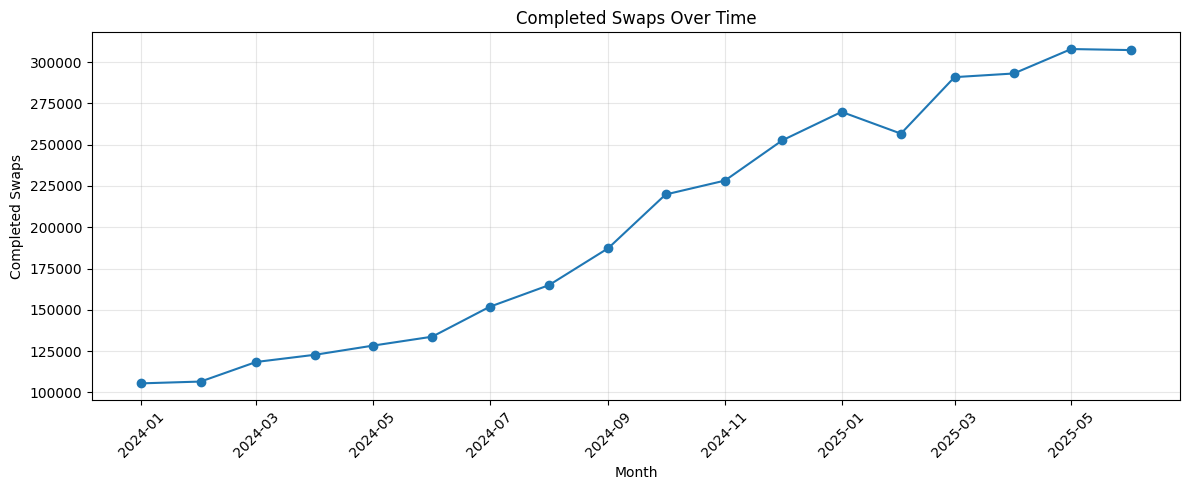

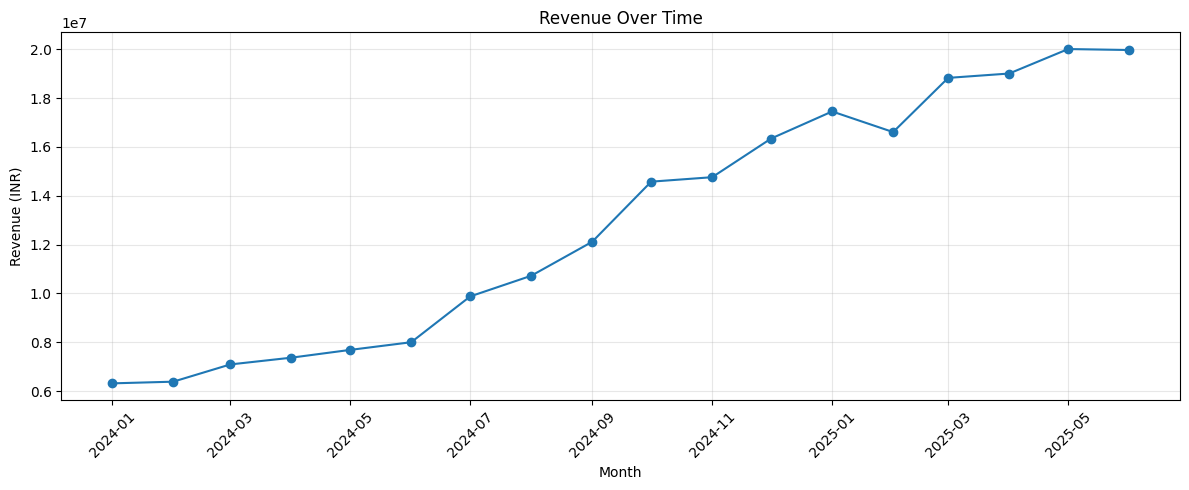

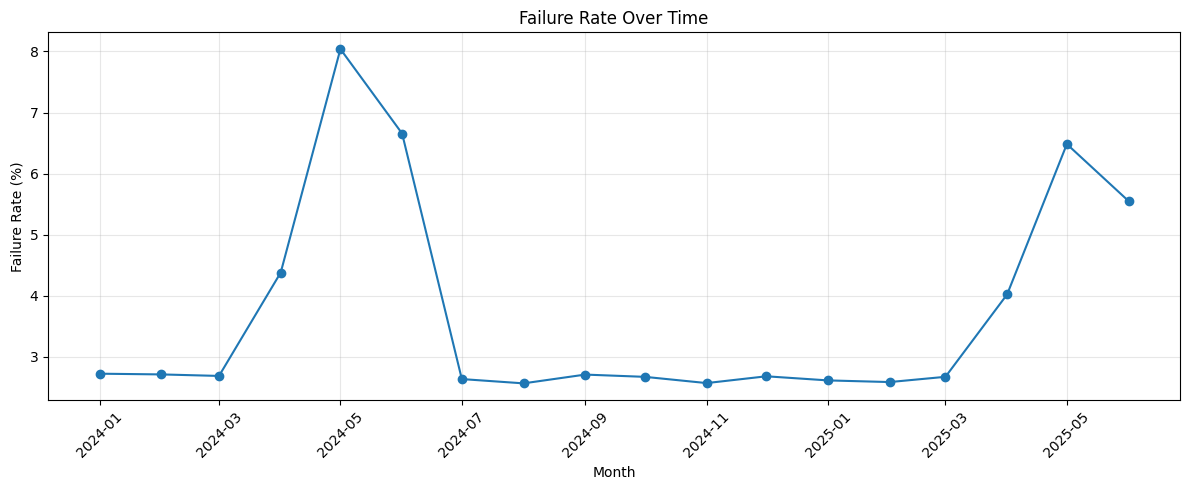

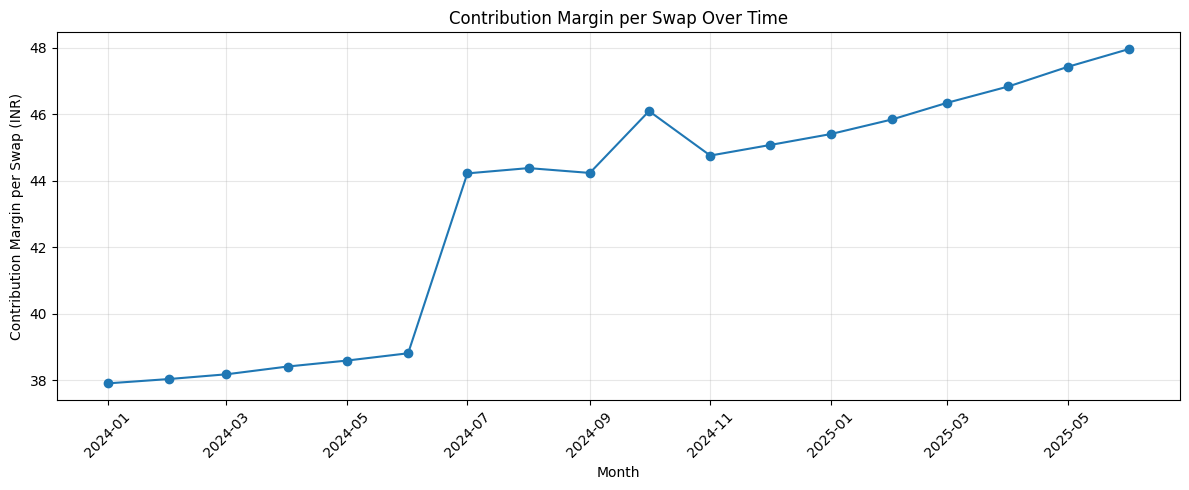

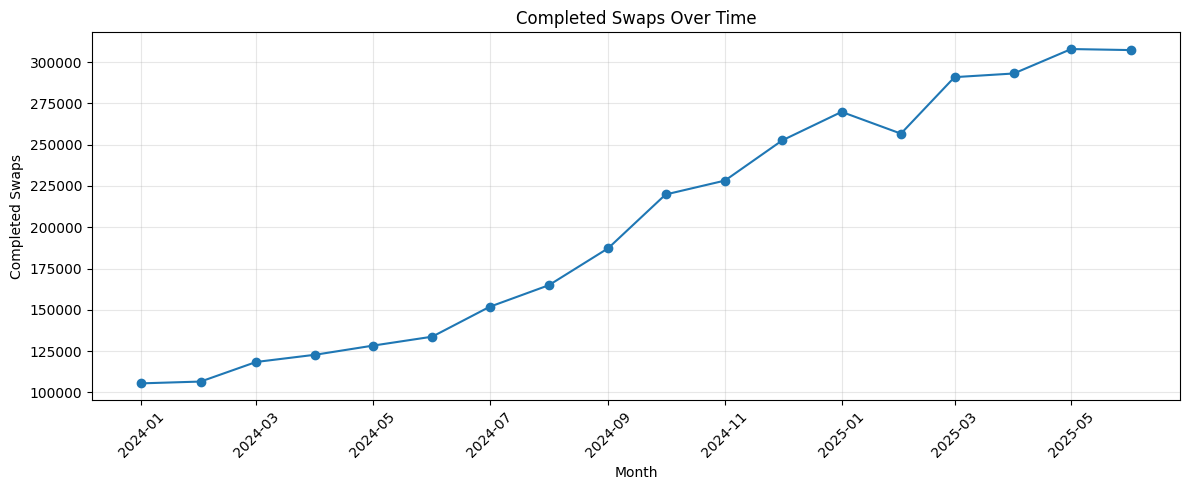

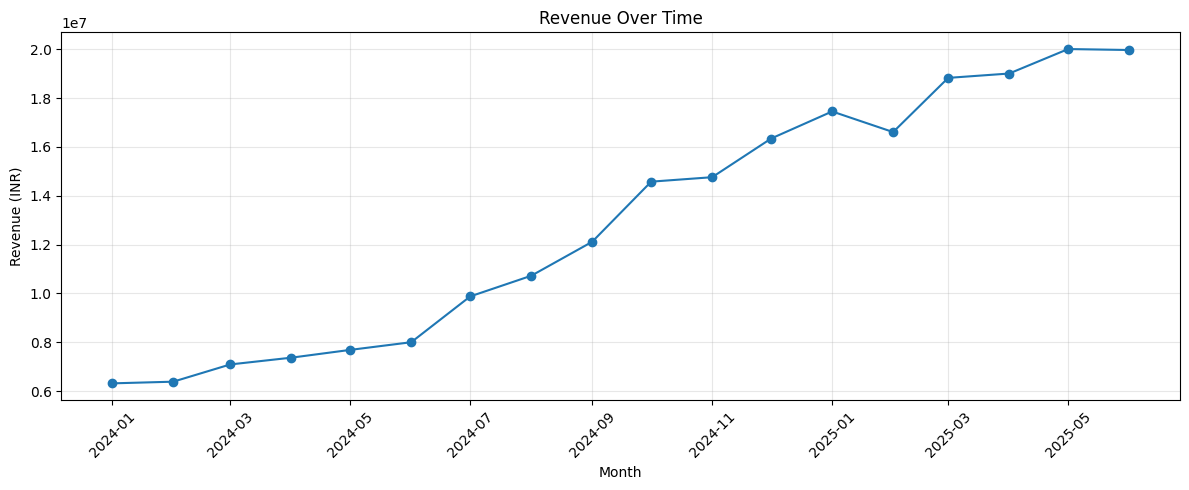

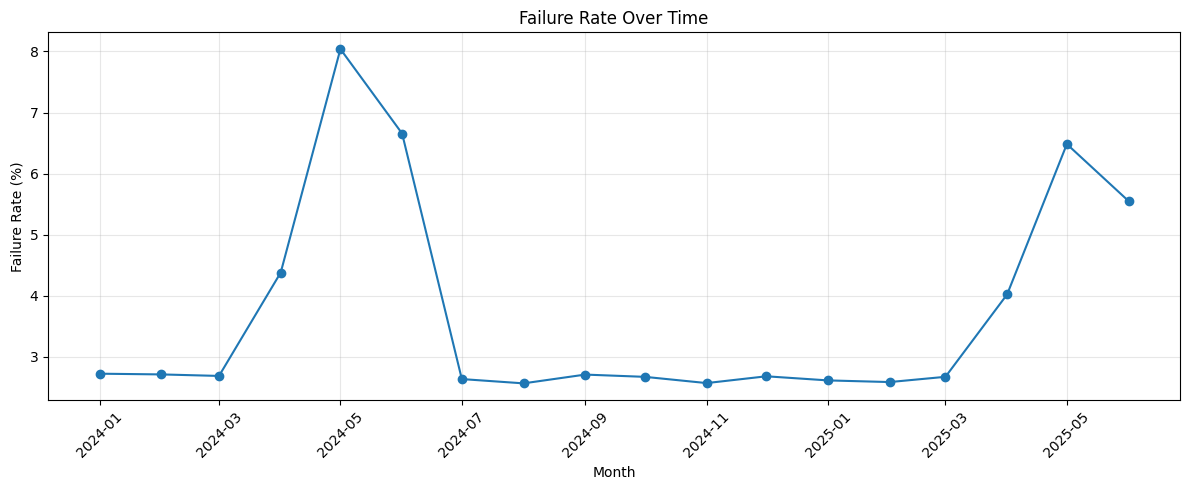

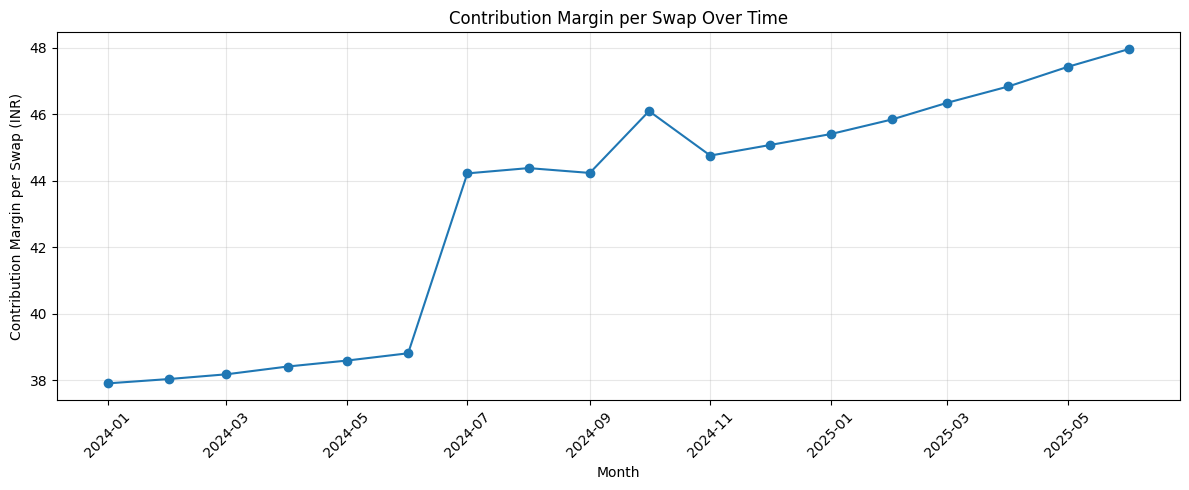

All 4 charts saved successfully!


In [ ]:
import matplotlib.pyplot as plt

# Make sure month is treated as a date
q1["month_date"] = pd.to_datetime(
    q1["month"],
    format="%Y-%m"
)

# -----------------------------
# 1. Completed Swaps
# -----------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    q1["month_date"],
    q1["completed_swaps"],
    marker="o"
)

plt.title("Completed Swaps Over Time")
plt.xlabel("Month")
plt.ylabel("Completed Swaps")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 2. Revenue
# -----------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    q1["month_date"],
    q1["revenue"],
    marker="o"
)

plt.title("Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 3. Failure Rate
# -----------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    q1["month_date"],
    q1["failure_rate"],
    marker="o"
)

plt.title("Failure Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


# -----------------------------
# 4. Contribution Margin per Swap
# -----------------------------
plt.figure(figsize=(12, 5))

plt.plot(
    q1["month_date"],
    q1["contribution_margin_per_swap"],
    marker="o"
)

plt.title("Contribution Margin per Swap Over Time")
plt.xlabel("Month")
plt.ylabel("Contribution Margin per Swap (INR)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()
import matplotlib.pyplot as plt

q1["month_date"] = pd.to_datetime(q1["month"], format="%Y-%m")

# 1. Completed Swaps
plt.figure(figsize=(12, 5))
plt.plot(q1["month_date"], q1["completed_swaps"], marker="o")
plt.title("Completed Swaps Over Time")
plt.xlabel("Month")
plt.ylabel("Completed Swaps")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Q1_Completed_Swaps.png", dpi=300)
plt.show()
plt.close()


# 2. Revenue
plt.figure(figsize=(12, 5))
plt.plot(q1["month_date"], q1["revenue"], marker="o")
plt.title("Revenue Over Time")
plt.xlabel("Month")
plt.ylabel("Revenue (INR)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Q1_Revenue.png", dpi=300)
plt.show()
plt.close()


# 3. Failure Rate
plt.figure(figsize=(12, 5))
plt.plot(q1["month_date"], q1["failure_rate"], marker="o")
plt.title("Failure Rate Over Time")
plt.xlabel("Month")
plt.ylabel("Failure Rate (%)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig("/content/drive/MyDrive/Q1_Failure_Rate.png", dpi=300)
plt.show()
plt.close()


# 4. Contribution Margin per Swap
plt.figure(figsize=(12, 5))
plt.plot(
    q1["month_date"],
    q1["contribution_margin_per_swap"],
    marker="o"
)
plt.title("Contribution Margin per Swap Over Time")
plt.xlabel("Month")
plt.ylabel("Contribution Margin per Swap (INR)")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(
    "/content/drive/MyDrive/Q1_Contribution_Margin.png",
    dpi=300
)
plt.show()
plt.close()

print("All 4 charts saved successfully!")

In [ ]:
findings = q1[
    [
        "month",
        "completed_swaps",
        "revenue",
        "failure_rate",
        "contribution_margin_per_swap"
    ]
].copy()

print(findings.to_string(index=False))

  month  completed_swaps     revenue  failure_rate  contribution_margin_per_swap
2024-01           105490  6318995.20      2.725922                     37.899554
2024-02           106582  6387614.80      2.714044                     38.030102
2024-03           118444  7093617.00      2.689266                     38.172220
2024-04           122836  7370255.80      4.381041                     38.406142
2024-05           128328  7689594.00      8.039486                     38.585225
2024-06           133743  8003275.60      6.656682                     38.804795
2024-07           151824  9879524.60      2.637881                     44.217085
2024-08           164931 10724296.65      2.567689                     44.375894
2024-09           187302 12115209.50      2.711285                     44.230513
2024-10           219838 14577271.65      2.674195                     46.091235
2024-11           228253 14759655.55      2.572246                     44.752909
2024-12           252621 163

In [ ]:
q1_submission = q1[
    [
        "month",
        "completed_swaps",
        "revenue",
        "failure_rate",
        "contribution_margin_per_swap"
    ]
].copy()

q1_submission.to_csv(
    "/content/drive/MyDrive/VoltRelay_Q1_Submission.csv",
    index=False
)

print("Q1 submission CSV saved!")

Q1 submission CSV saved!


In [ ]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    for file in files:
        if file in [
            'station_hourly_status.csv',
            'station_hourly_status.csv.gz',
            'support_tickets.csv',
            'support_tickets.csv.gz'
        ]:
            print(os.path.join(root, file))

In [ ]:
import os

dashboard_folder = "/content/drive/MyDrive/VoltRelay_Dashboard"

os.makedirs(dashboard_folder, exist_ok=True)

print("Dashboard folder created:")
print(dashboard_folder)


Dashboard folder created:
/content/drive/MyDrive/VoltRelay_Dashboard


In [ ]:
import shutil

source = "/content/drive/MyDrive/VoltRelay_Q1_Submission.csv"
destination = "/content/drive/MyDrive/VoltRelay_Dashboard/VoltRelay_Q1_Submission.csv"

shutil.copy(source, destination)

print("Q1 CSV copied successfully!")

Q1 CSV copied successfully!


In [ ]:
dashboard_code = r'''
import streamlit as st
import pandas as pd
import plotly.express as px

# -----------------------------
# Page configuration
# -----------------------------
st.set_page_config(
    page_title="VoltRelay Network Performance",
    page_icon="⚡",
    layout="wide"
)

# -----------------------------
# Load data
# -----------------------------
df = pd.read_csv("VoltRelay_Q1_Submission.csv")

df["month"] = pd.to_datetime(df["month"])

# -----------------------------
# Title
# -----------------------------
st.title("⚡ VoltRelay Network Performance Dashboard")

st.markdown(
    "### Q1 — Network Performance Over Time"
)

st.caption(
    "Analysis period: January 2024 – June 2025"
)

# -----------------------------
# KPI calculations
# -----------------------------
total_swaps = df["completed_swaps"].sum()
total_revenue = df["revenue"].sum()
average_failure = df["failure_rate"].mean()
latest_margin = df.iloc[-1]["contribution_margin_per_swap"]

# -----------------------------
# KPI cards
# -----------------------------
col1, col2, col3, col4 = st.columns(4)

with col1:
    st.metric(
        "Total Completed Swaps",
        f"{total_swaps:,.0f}"
    )

with col2:
    st.metric(
        "Total Revenue",
        f"₹{total_revenue:,.0f}"
    )

with col3:
    st.metric(
        "Average Failure Rate",
        f"{average_failure:.2f}%"
    )

with col4:
    st.metric(
        "Latest Margin / Swap",
        f"₹{latest_margin:.2f}"
    )

st.divider()

# -----------------------------
# Completed swaps
# -----------------------------
st.subheader("1. Completed Swaps Over Time")

fig1 = px.line(
    df,
    x="month",
    y="completed_swaps",
    markers=True,
    labels={
        "month": "Month",
        "completed_swaps": "Completed Swaps"
    }
)

fig1.update_layout(
    hovermode="x unified"
)

st.plotly_chart(
    fig1,
    use_container_width=True
)

# -----------------------------
# Revenue
# -----------------------------
st.subheader("2. Revenue Over Time")

fig2 = px.line(
    df,
    x="month",
    y="revenue",
    markers=True,
    labels={
        "month": "Month",
        "revenue": "Revenue (INR)"
    }
)

fig2.update_layout(
    hovermode="x unified"
)

st.plotly_chart(
    fig2,
    use_container_width=True
)

# -----------------------------
# Failure rate
# -----------------------------
st.subheader("3. Failure Rate Over Time")

fig3 = px.line(
    df,
    x="month",
    y="failure_rate",
    markers=True,
    labels={
        "month": "Month",
        "failure_rate": "Failure Rate (%)"
    }
)

fig3.update_layout(
    hovermode="x unified"
)

st.plotly_chart(
    fig3,
    use_container_width=True
)

# -----------------------------
# Contribution margin
# -----------------------------
st.subheader("4. Contribution Margin per Swap")

fig4 = px.line(
    df,
    x="month",
    y="contribution_margin_per_swap",
    markers=True,
    labels={
        "month": "Month",
        "contribution_margin_per_swap":
            "Contribution Margin / Swap (INR)"
    }
)

fig4.update_layout(
    hovermode="x unified"
)

st.plotly_chart(
    fig4,
    use_container_width=True
)

# -----------------------------
# Key findings
# -----------------------------
st.divider()

st.subheader("Key Findings")

st.markdown("""
- Completed swaps increased substantially during the analysis period.
- Monthly revenue increased alongside network activity.
- Failure rates were generally around 2.6–2.7% in many months, with noticeable spikes in selected periods.
- Contribution margin per completed swap increased over the analysis period.
""")

# -----------------------------
# Monthly data
# -----------------------------
with st.expander("View Monthly Data"):
    display_df = df.copy()
    display_df["month"] = display_df["month"].dt.strftime("%Y-%m")
    st.dataframe(
        display_df,
        use_container_width=True
    )
'''

with open(
    "/content/drive/MyDrive/VoltRelay_Dashboard/app.py",
    "w"
) as f:
    f.write(dashboard_code)

print("Streamlit app created successfully!")

Streamlit app created successfully!
